In [1]:
# Plot style
import matplotlib as mpl
mpl.rcParams["font.family"] = "UbuntuSansMono NF"

# Source Term Test (Full vs Analytic Series)

This notebook loads precomputed grids and evaluates the L=2 source term using `source_aux`.
It compares the full (non-polynomial) source with analytic series (r^3, r^5, r^7) on a 5x5 grid over 25 pc values.

In [2]:
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import sys
from pathlib import Path

# Add parent directory to path to import helper functions
sys.path.append(str(Path.cwd().parent))

from EOS_aux import PolytropeEOS_n1
from solver_tov import cgs_to_geom, nu_rhs, rk4_step_nu
from source_aux import source_full, source_r3, source_r5, source_r7


In [3]:
# Load config
config_path = Path("/Users/sztk.ch/Work/grad-school/Research/TLN-TDN Project/Programs/Equation Solver/high_bg_order_sol/config/h_eps_config.pkl")
with open(config_path, "rb") as f:
    h_eps_dic = pickle.load(f)

h_str = str(h_eps_dic["h"])
eps_str = str(h_eps_dic["eps"])
d_num = int(h_eps_dic["d_num"])
K_cgs = float(h_eps_dic["K_cgs"])

print(f"Using h = {h_str}, eps = {eps_str}, d_num = {d_num}, K_cgs = {K_cgs}")


Using h = 1e-4, eps = 1e-3, d_num = 25, K_cgs = 160000.0


In [4]:
# Load grids
grid_dir = Path("/Users/sztk.ch/Work/grad-school/Research/TLN-TDN Project/Programs/Equation Solver/high_bg_order_sol/numpy_grid")
target_dir = grid_dir / f"h{h_str}_eps{eps_str}"

rgrid_path = target_dir / f"RGrid_h{h_str}_eps{eps_str}.pkl"
pmsol_path = target_dir / f"PMSolGrid_h{h_str}_eps{eps_str}.pkl"
u_path = target_dir / f"U00Grid_h{h_str}_eps{eps_str}.pkl"
nu_path = target_dir / f"NuGrid_h{h_str}_eps{eps_str}.pkl"

source_path = target_dir / f"SourceGrid_full_h{h_str}_eps{eps_str}.pkl"

if not rgrid_path.exists():
    alt = target_dir / f"Rgrid_h{h_str}_eps{eps_str}.pkl"
    if alt.exists():
        rgrid_path = alt

print("Loading:")
print(" ", rgrid_path)
print(" ", pmsol_path)
print(" ", u_path)
print(" ", nu_path)
print(" ", source_path)

with open(rgrid_path, "rb") as f:
    Rgrid = pickle.load(f)
with open(pmsol_path, "rb") as f:
    PMSol = pickle.load(f)
with open(u_path, "rb") as f:
    UGrid = pickle.load(f)
with open(nu_path, "rb") as f:
    NuGrid = pickle.load(f)
with open(source_path, "rb") as f:
    SourceFull = pickle.load(f)

print(f"Loaded {len(Rgrid)} models")


Loading:
  /Users/sztk.ch/Work/grad-school/Research/TLN-TDN Project/Programs/Equation Solver/high_bg_order_sol/numpy_grid/h1e-4_eps1e-3/RGrid_h1e-4_eps1e-3.pkl
  /Users/sztk.ch/Work/grad-school/Research/TLN-TDN Project/Programs/Equation Solver/high_bg_order_sol/numpy_grid/h1e-4_eps1e-3/PMSolGrid_h1e-4_eps1e-3.pkl
  /Users/sztk.ch/Work/grad-school/Research/TLN-TDN Project/Programs/Equation Solver/high_bg_order_sol/numpy_grid/h1e-4_eps1e-3/U00Grid_h1e-4_eps1e-3.pkl
  /Users/sztk.ch/Work/grad-school/Research/TLN-TDN Project/Programs/Equation Solver/high_bg_order_sol/numpy_grid/h1e-4_eps1e-3/NuGrid_h1e-4_eps1e-3.pkl
  /Users/sztk.ch/Work/grad-school/Research/TLN-TDN Project/Programs/Equation Solver/high_bg_order_sol/numpy_grid/h1e-4_eps1e-3/SourceGrid_full_h1e-4_eps1e-3.pkl


/var/folders/2w/8nb8998n2h38fndcsz3s5wq80000gn/T/ipykernel_66921/2184854234.py:27: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  PMSol = pickle.load(f)


Loaded 25 models


/var/folders/2w/8nb8998n2h38fndcsz3s5wq80000gn/T/ipykernel_66921/2184854234.py:29: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  UGrid = pickle.load(f)
/var/folders/2w/8nb8998n2h38fndcsz3s5wq80000gn/T/ipykernel_66921/2184854234.py:31: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage

In [13]:
# Load concatenated data
concat_path = target_dir / f"SourceGrid_concat_h{h_str}_eps{eps_str}.pkl"
with open(concat_path, "rb") as f:
    SourceConcat = pickle.load(f)

/var/folders/2w/8nb8998n2h38fndcsz3s5wq80000gn/T/ipykernel_66921/2588744628.py:4: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  SourceConcat = pickle.load(f)


/var/folders/2w/8nb8998n2h38fndcsz3s5wq80000gn/T/ipykernel_66921/53904229.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.97])


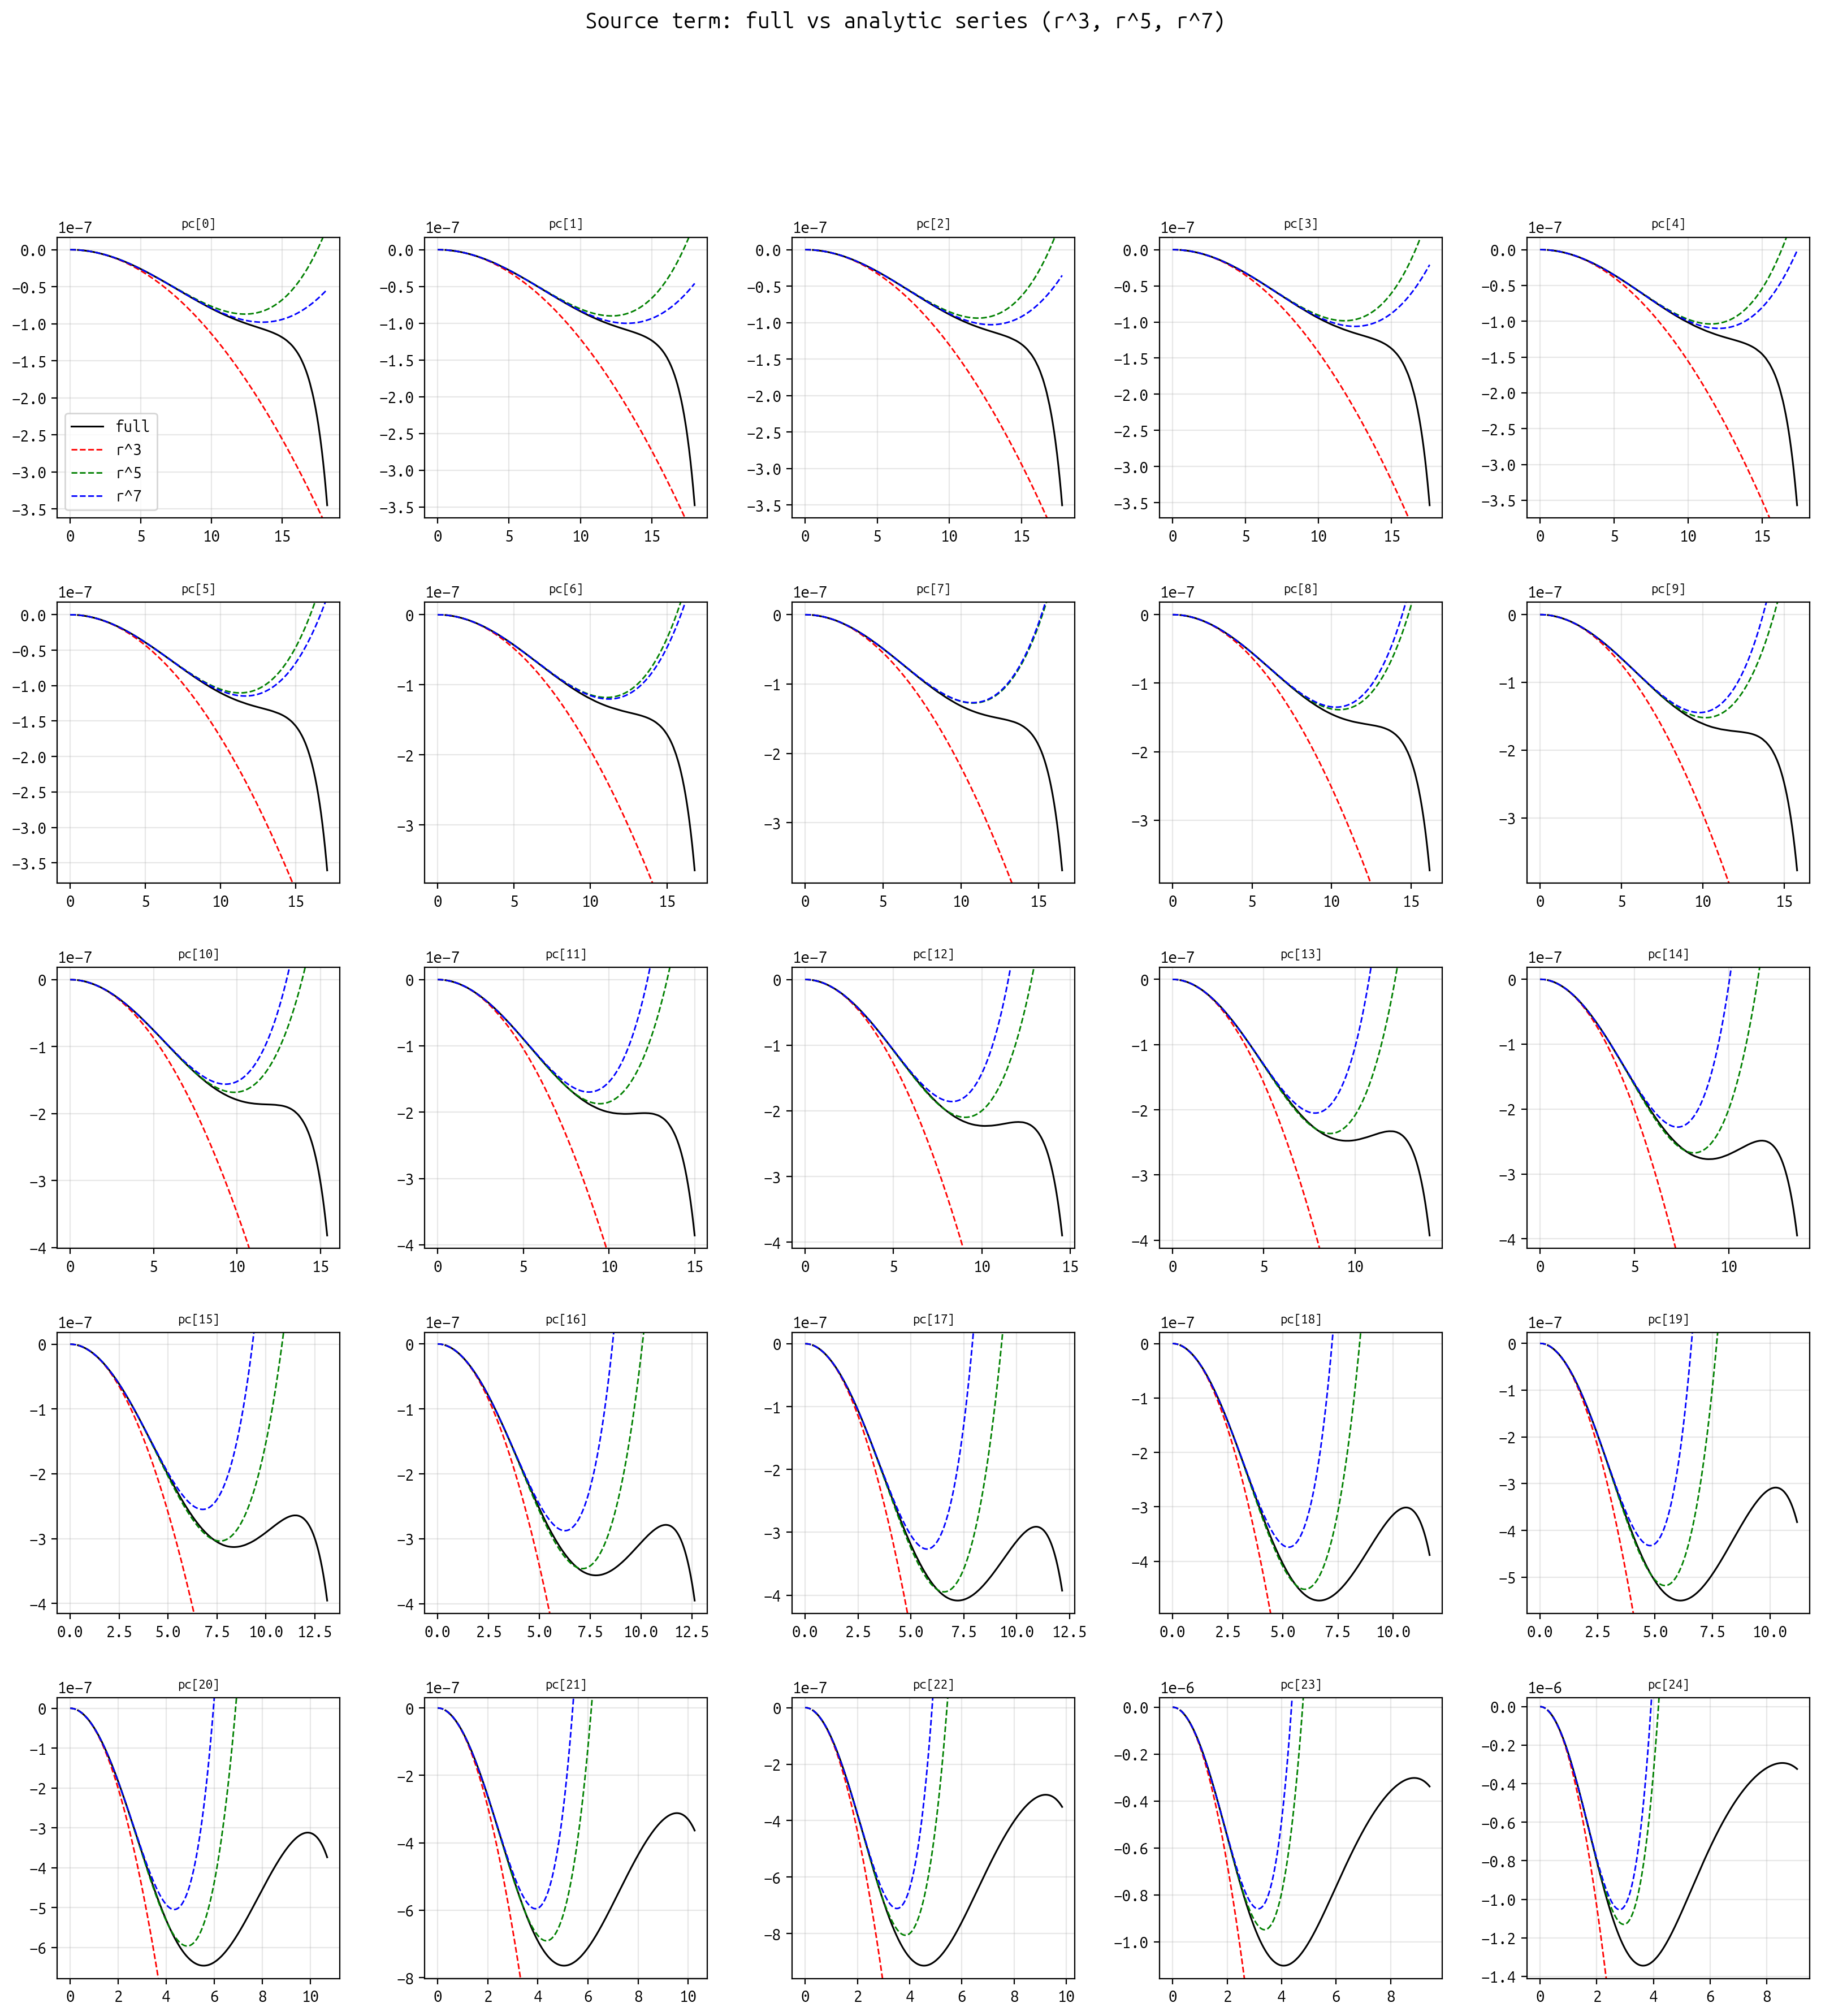

In [5]:
# Compute and plot sources (5x5 grid): full vs r^3/r^5/r^7 (no error panel)
n_models = min(d_num, 25)
grid_n = 5

fig = plt.figure(figsize=(20, 20), dpi=200)
outer = fig.add_gridspec(grid_n, grid_n, wspace=0.3, hspace=0.3)

PcArr_cgs = np.logspace(33.5, 36.5, d_num)
K_geom, PcArr = cgs_to_geom(PcArr_cgs, 1, K_cgs)[:2]

for idx in range(n_models):
    i = idx // grid_n
    j = idx % grid_n
    ax = fig.add_subplot(outer[i, j])

    PMSolArr = np.array(PMSol[idx])
    RArr = np.array(Rgrid[idx])
    PArr = PMSolArr[:, 1]
    MArr = PMSolArr[:, 0]

    r = RArr[:-1]
    P = PArr[:-1]
    M = MArr[:-1]

    u_num = np.array(UGrid[idx])[:, 0]
    du_num = np.array(UGrid[idx])[:, 1]

    # Align lengths defensively (UGrid length may differ by 1)
    n = min(len(r), len(u_num))
    r = r[:n]
    P = P[:n]
    M = M[:n]
    u_num = u_num[:n]
    du_num = du_num[:n]

    h00 = u_num * (r**2)
    dh00 = du_num * (r**2) + 2.0 * u_num * r

    n1polytrope = PolytropeEOS_n1(K_geom)
    rho = n1polytrope.energy_density(P)
    drho = np.gradient(rho, r, edge_order=2)
    d2rho = np.gradient(drho, r, edge_order=2)

    lamb = np.log(r / (r - 2.0 * M))
    nu = np.array(NuGrid[idx])[:-1]

    # Match solver-source_old.ipynb: enforce a common length and trim by 4
    arr_len = min(len(r), len(P), len(M), len(rho), len(lamb), len(nu), len(drho), len(d2rho), len(h00), len(dh00))
    arr_len = max(arr_len - 4, 0)

    r = r[:arr_len]
    P = P[:arr_len]
    M = M[:arr_len]
    rho = rho[:arr_len]
    drho = drho[:arr_len]
    d2rho = d2rho[:arr_len]
    h00 = h00[:arr_len]
    dh00 = dh00[:arr_len]
    lamb = lamb[:arr_len]
    nu = nu[:arr_len]

    # eta, deta, d2eta follow solver-source_old.ipynb convention
    T = 6e-6
    eta = T * rho**2
    deta = 2.0 * T * rho
    d2eta = 2.0 * T

    src_full = np.array(SourceFull[idx])

    pc = PcArr[idx]

    src_r3 = source_r3(r, K_geom, pc, a0=1.0, nu_c=nu[0], T=T)
    src_r5 = source_r5(r, K_geom, pc, a0=1.0, nu_c=nu[0], T=T)
    src_r7 = source_r7(r, K_geom, pc, a0=1.0, nu_c=nu[0], T=T)

    src_num = np.array(src_full)
    if np.iscomplexobj(src_num):
        src_num = src_num.imag

    starting_ind = int(0.03 * len(r))
    ax.plot(r[starting_ind:], src_num[starting_ind:], 'k-', linewidth=1.1, label="full")
    ax.plot(r, src_r3, 'r--', linewidth=1.0, label="r^3")
    ax.plot(r, src_r5, 'g--', linewidth=1.0, label="r^5")
    ax.plot(r, src_r7, 'b--', linewidth=1.0, label="r^7")

    scale = (np.max(src_num[starting_ind:]) - np.min(src_num[starting_ind:])) * 0.05
    ax.set_ylim(np.min(src_num[starting_ind:]) - scale, np.max(src_num[starting_ind:]) + scale)

    ax.set_title(f"pc[{idx}]", fontsize=8)
    ax.grid(alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=10)

fig.suptitle("Source term: full vs analytic series (r^3, r^5, r^7)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


/var/folders/2w/8nb8998n2h38fndcsz3s5wq80000gn/T/ipykernel_66921/2541051811.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.97])


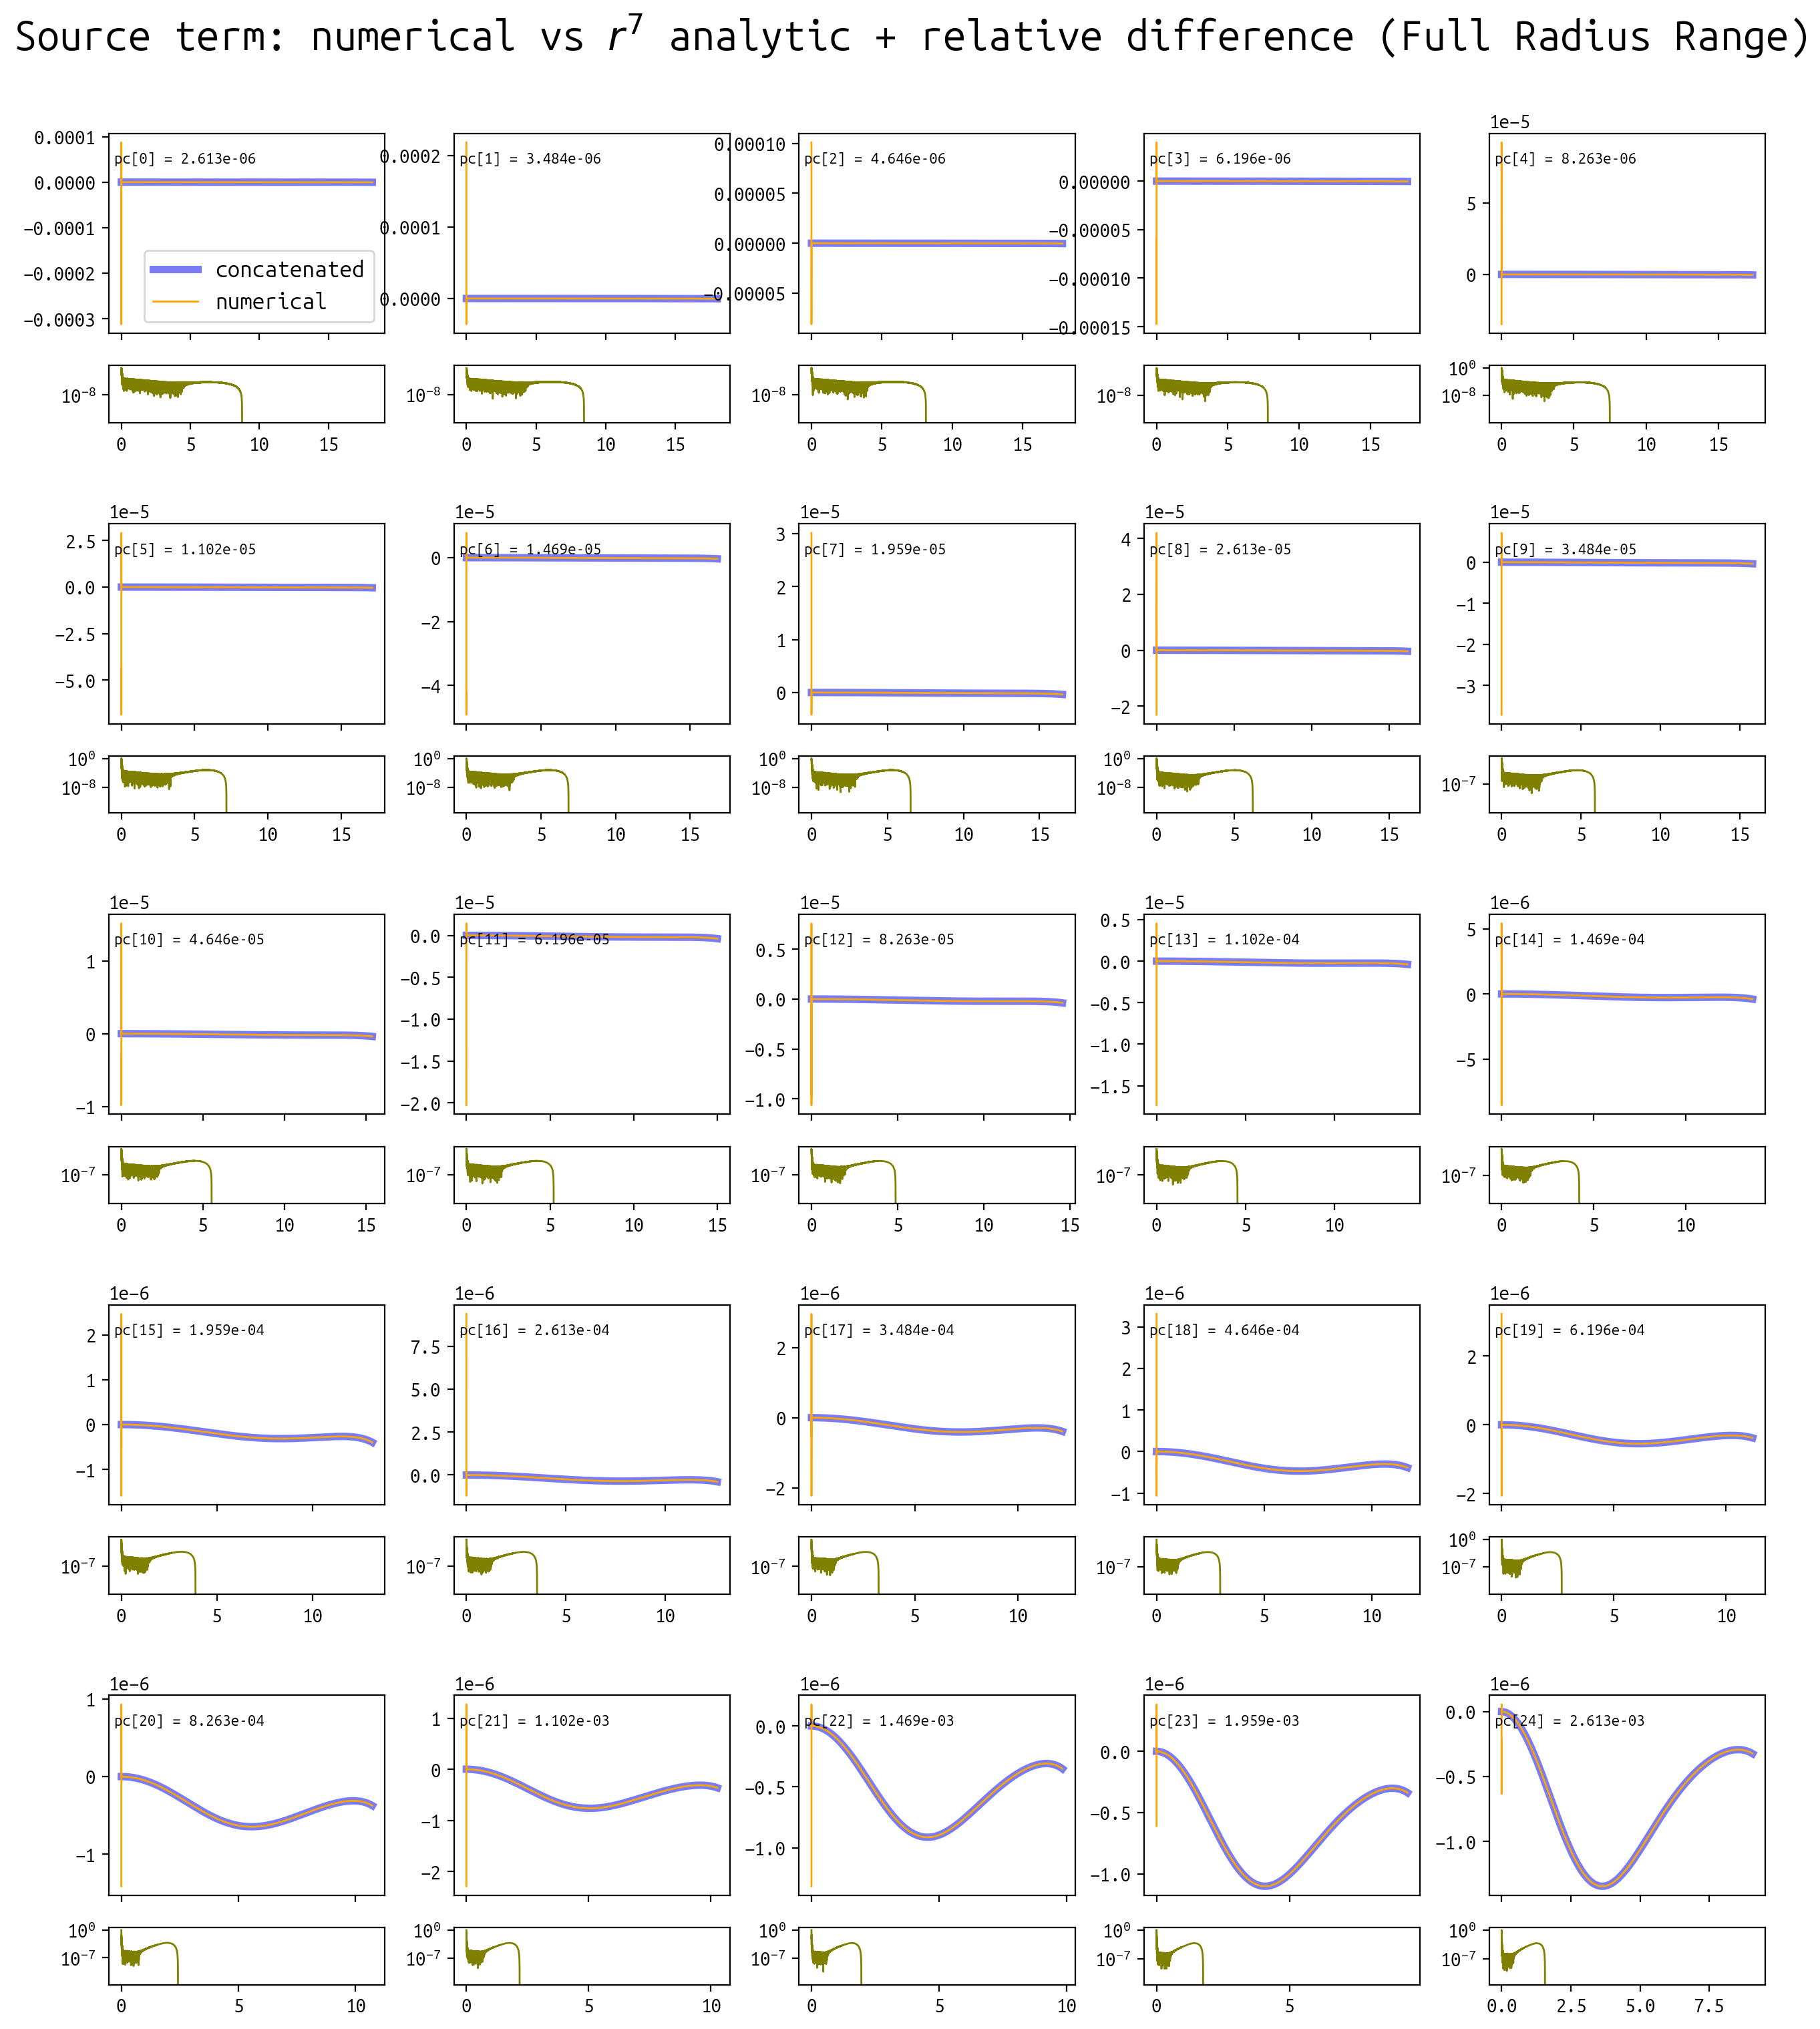

In [19]:
# Compute and plot sources (5x5 grid): r^7 overlay + relative difference
n_models = min(d_num, 25)
grid_n = 5

fig = plt.figure(figsize=(16, 18), dpi=200)
outer = fig.add_gridspec(grid_n, grid_n, wspace=0.25, hspace=0.35)

PcArr_cgs = np.logspace(33.5, 36.5, d_num)
K_geom, PcArr = cgs_to_geom(PcArr_cgs, 1, K_cgs)[:2]

for idx in range(n_models):
    i = idx // grid_n
    j = idx % grid_n

    inner = outer[i, j].subgridspec(2, 1, height_ratios=[3.5, 1], hspace=0.25)
    ax_top = fig.add_subplot(inner[0])
    ax_bot = fig.add_subplot(inner[1], sharex=ax_top)

    PMSolArr = np.array(PMSol[idx])
    RArr = np.array(Rgrid[idx])
    PArr = PMSolArr[:, 1]
    MArr = PMSolArr[:, 0]

    r = RArr[:-1]
    P = PArr[:-1]
    M = MArr[:-1]

    u_num = np.array(UGrid[idx])[:, 0]
    du_num = np.array(UGrid[idx])[:, 1]

    # Align lengths defensively (UGrid length may differ by 1)
    n = min(len(r), len(u_num))
    r = r[:n]
    P = P[:n]
    M = M[:n]
    u_num = u_num[:n]
    du_num = du_num[:n]

    h00 = u_num * (r**2)
    dh00 = du_num * (r**2) + 2.0 * u_num * r

    n1polytrope = PolytropeEOS_n1(K_geom)
    rho = n1polytrope.energy_density(P)
    drho = np.gradient(rho, r, edge_order=2)
    d2rho = np.gradient(drho, r, edge_order=2)

    lamb = np.log(r / (r - 2.0 * M))
    nu = np.array(NuGrid[idx])[:-1]

    # Match solver-source_old.ipynb: enforce a common length and trim by 4
    arr_len = min(len(r), len(P), len(M), len(rho), len(lamb), len(nu), len(drho), len(d2rho), len(h00), len(dh00))
    arr_len = max(arr_len - 4, 0)

    r = r[:arr_len]
    P = P[:arr_len]
    M = M[:arr_len]
    rho = rho[:arr_len]
    drho = drho[:arr_len]
    d2rho = d2rho[:arr_len]
    h00 = h00[:arr_len]
    dh00 = dh00[:arr_len]
    lamb = lamb[:arr_len]
    nu = nu[:arr_len]

    # eta, deta, d2eta follow solver-source_old.ipynb convention
    T = 6e-6
    eta = T * rho**2
    deta = 2.0 * T * rho
    d2eta = 2.0 * T

    src_full = np.array(SourceFull[idx])

    pc = PcArr[idx]
    src_r7 = source_r7(r, K_geom, pc, a0=1.0, nu_c=nu[0], T=T)

    src_num = np.array(src_full)
    if np.iscomplexobj(src_num):
        src_num = src_num.imag
    
    src_concat = np.array(SourceConcat[idx])
    if np.iscomplexobj(src_concat):
        src_concat = src_concat.imag

    # =========================
    # Top panel: numerical vs r^7 analytical
    # =========================
    ax_top.plot(r, src_concat, color="#2025ed", alpha=0.6, lw=4.0, label="concatenated")
    ax_top.plot(r, src_num, color="orange", lw=1.0, label="numerical")
    ax_top.text(0.02, 0.85, f"pc[{idx}] = {pc:.3e}", transform=ax_top.transAxes, fontsize=8)

    if idx == 0:
        ax_top.legend(fontsize=12)

    # ax_top.set_yscale("log")
    ax_top.tick_params(labelbottom=False)

    # =========================
    # Bottom panel: relative difference with softening
    # =========================
    soft_slice = src_num[int(0.1 * len(src_num)) : int(0.2 * len(src_num))]
    softening = np.max(np.abs(soft_slice)) * 0.1 if len(soft_slice) else 0.0
    if not np.isfinite(softening) or softening == 0.0:
        softening = 1e-30

    diff_concat = np.abs(src_num - src_concat) / (np.abs(src_num) + softening)

    ax_bot.axhline(0.0, lw=0.8, alpha=0.6)
    ax_bot.plot(r, diff_concat, color="olive", lw=1.0, label=r"|num - $r^7$|/(|num|+soft)")
    # ax_bot.set_ylim(-0.01, 0.1)
    ax_bot.set_yscale("log")

fig.suptitle("Source term: numerical vs $r^7$ analytic + relative difference (Full Radius Range)", fontsize=22, y=0.93)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


/var/folders/2w/8nb8998n2h38fndcsz3s5wq80000gn/T/ipykernel_66921/2088584673.py:7: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  SourceConcat = pickle.load(f)
/var/folders/2w/8nb8998n2h38fndcsz3s5wq80000gn/T/ipykernel_66921/2088584673.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.97])


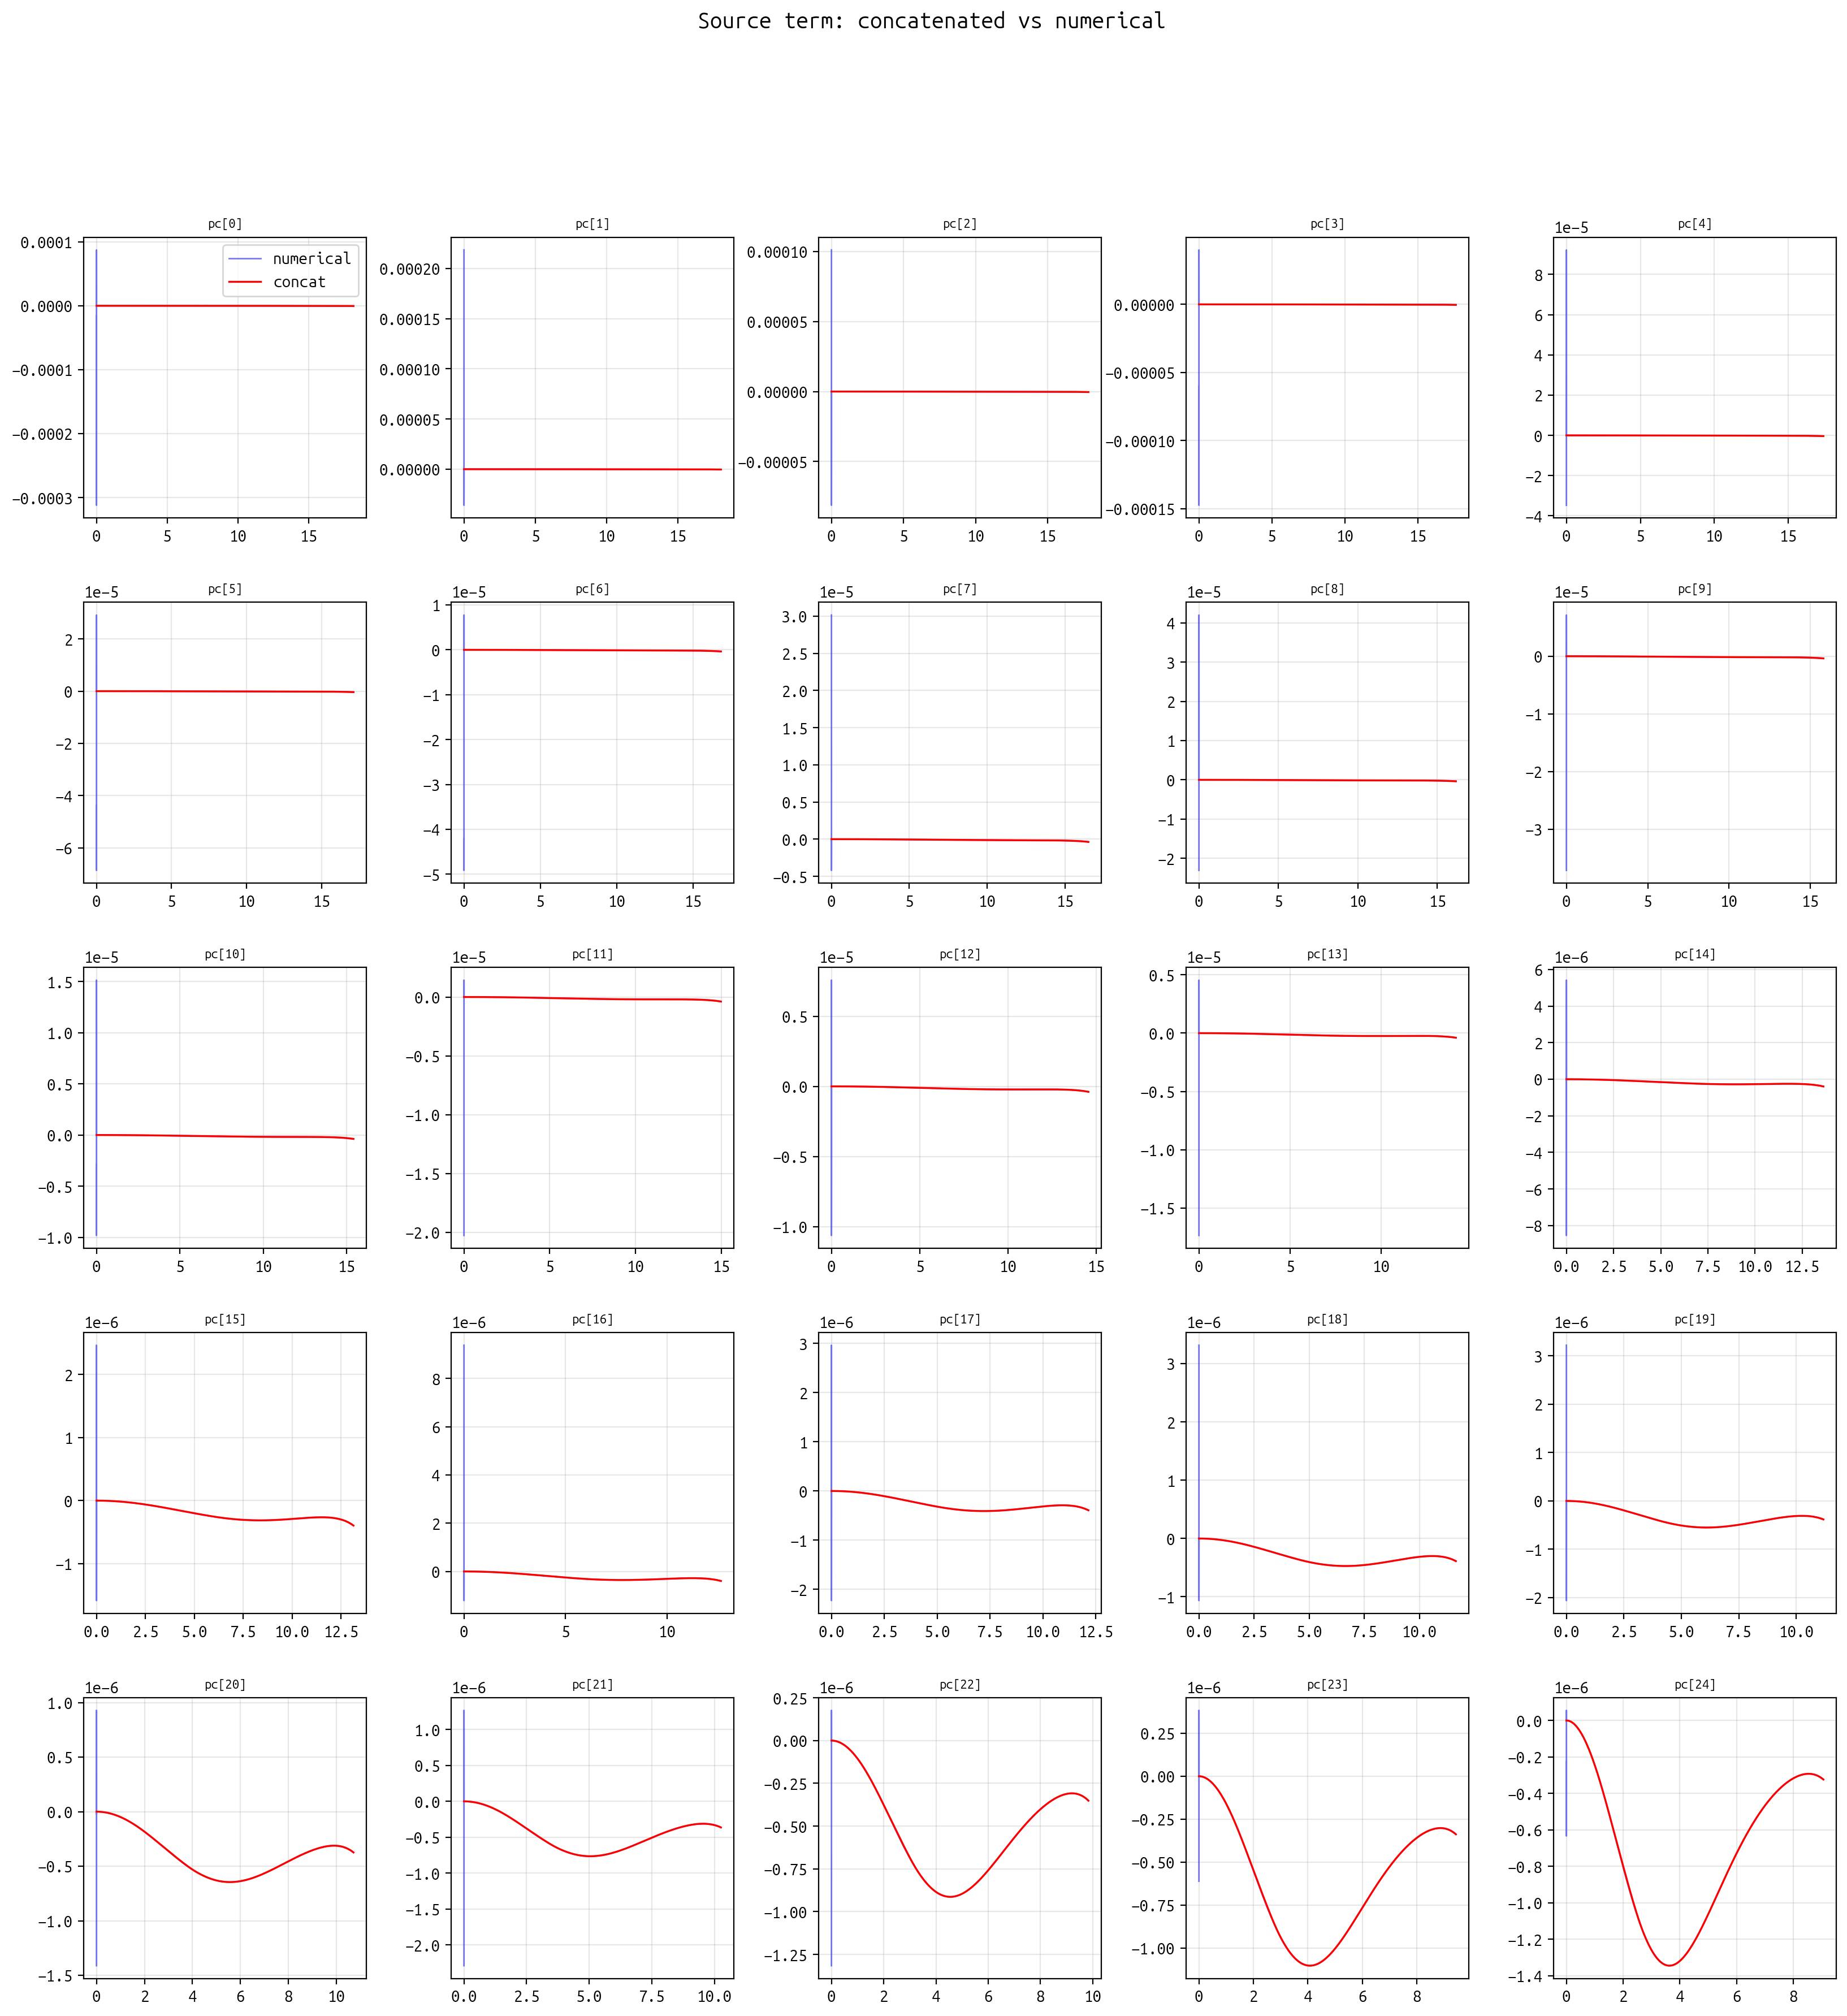

In [ ]:
# Plot concatenated source vs numerical (5x5 grid)
n_models = min(d_num, 25)
grid_n = 5

fig = plt.figure(figsize=(20, 20), dpi=200)
outer = fig.add_gridspec(grid_n, grid_n, wspace=0.3, hspace=0.3)

for idx in range(n_models):
    i = idx // grid_n
    j = idx % grid_n
    ax = fig.add_subplot(outer[i, j])

    RArr = np.array(Rgrid[idx])
    r = RArr[:-1]

    src_num = np.array(SourceFull[idx])
    if np.iscomplexobj(src_num):
        src_num = src_num.imag

    src_concat = np.array(SourceConcat[idx])
    if np.iscomplexobj(src_concat):
        src_concat = src_concat.imag

    n = min(len(r), len(src_num), len(src_concat))
    r = r[:n]
    src_num = src_num[:n]
    src_concat = src_concat[:n]

    ax.plot(r, src_num, color="#2025ed", lw=1.0, alpha=0.6, label="numerical")
    ax.plot(r, src_concat, color="red", lw=1.2, label="concat")

    ax.set_title(f"pc[{idx}]", fontsize=8)
    ax.grid(alpha=0.3)
    
    if idx == 0:
        ax.legend(fontsize=10)

fig.suptitle("Source term: concatenated vs numerical", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


/var/folders/2w/8nb8998n2h38fndcsz3s5wq80000gn/T/ipykernel_66921/4202394612.py:111: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.99])


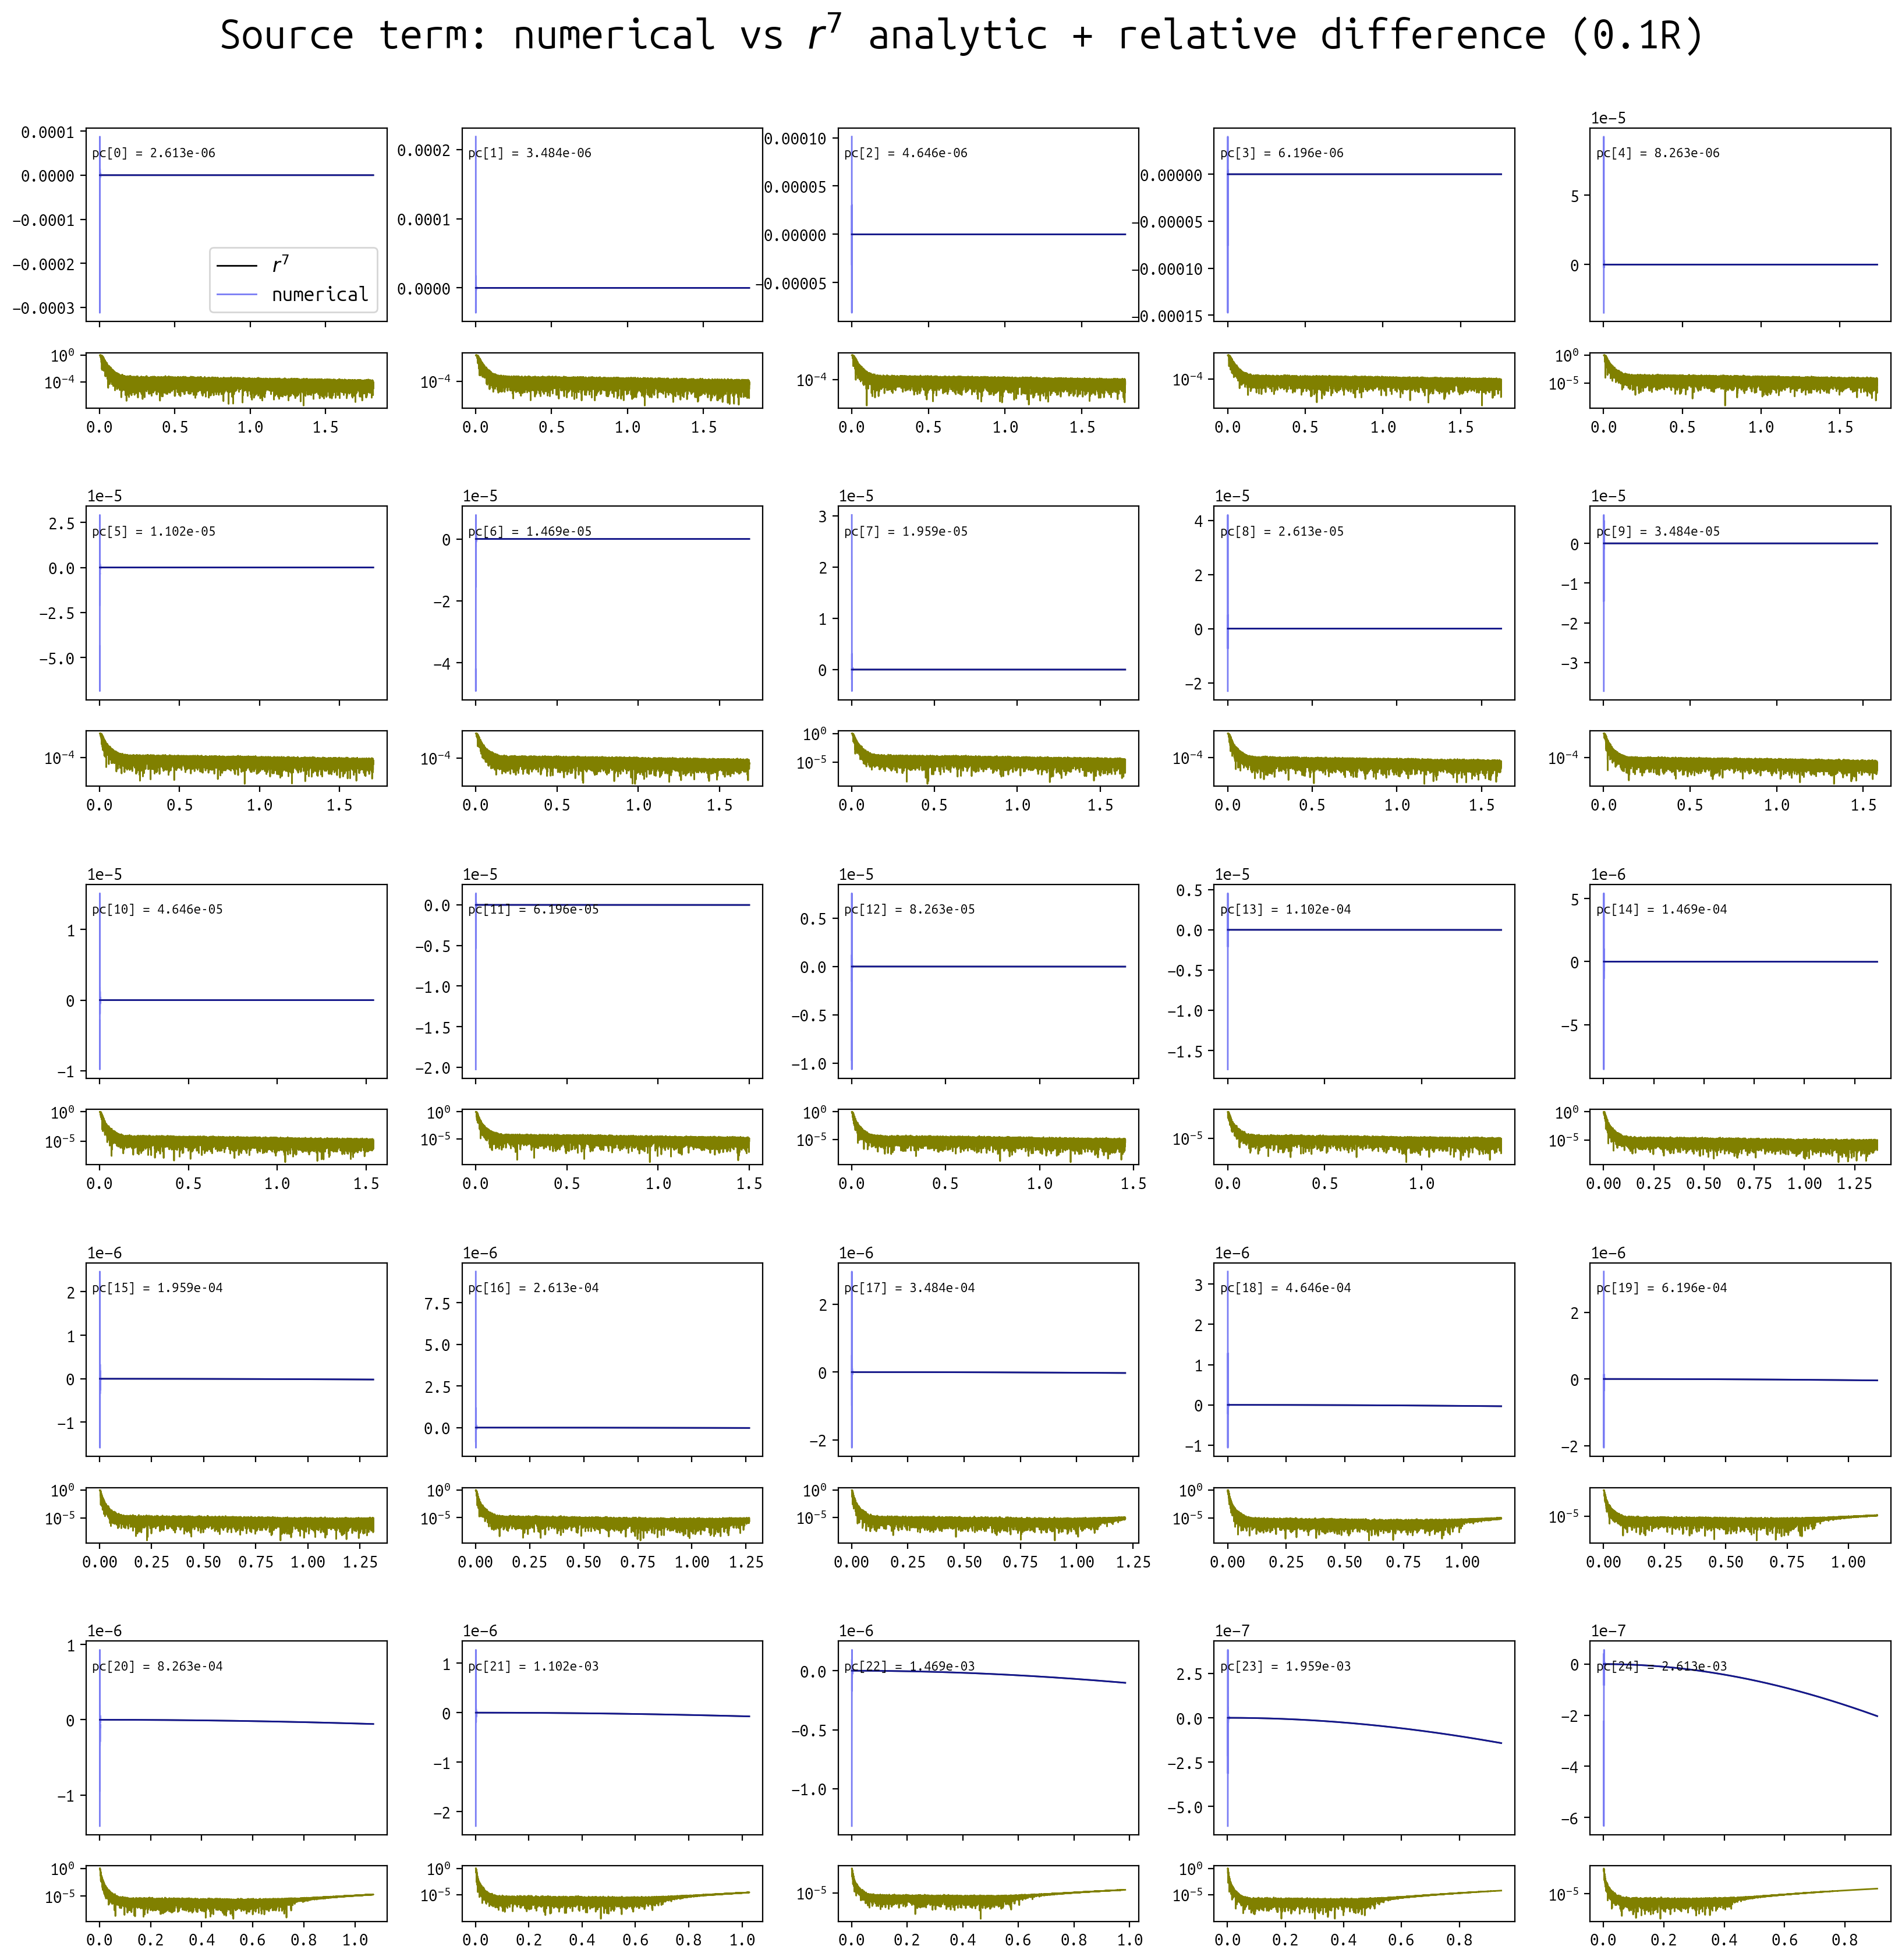

In [8]:
# Compute and plot sources (5x5 grid): r^7 overlay + relative difference
n_models = min(d_num, 25)
grid_n = 5

fig = plt.figure(figsize=(20, 20), dpi=200)
outer = fig.add_gridspec(grid_n, grid_n, wspace=0.25, hspace=0.35)

PcArr_cgs = np.logspace(33.5, 36.5, d_num)
K_geom, PcArr = cgs_to_geom(PcArr_cgs, 1, K_cgs)[:2]

for idx in range(n_models):
    i = idx // grid_n
    j = idx % grid_n

    inner = outer[i, j].subgridspec(2, 1, height_ratios=[3.5, 1], hspace=0.25)
    ax_top = fig.add_subplot(inner[0])
    ax_bot = fig.add_subplot(inner[1], sharex=ax_top)

    PMSolArr = np.array(PMSol[idx])
    RArr = np.array(Rgrid[idx])
    PArr = PMSolArr[:, 1]
    MArr = PMSolArr[:, 0]

    r = RArr[:-1]
    P = PArr[:-1]
    M = MArr[:-1]

    u_num = np.array(UGrid[idx])[:, 0]
    du_num = np.array(UGrid[idx])[:, 1]

    # Align lengths defensively (UGrid length may differ by 1)
    n = min(len(r), len(u_num))
    r = r[:n]
    P = P[:n]
    M = M[:n]
    u_num = u_num[:n]
    du_num = du_num[:n]

    h00 = u_num * (r**2)
    dh00 = du_num * (r**2) + 2.0 * u_num * r

    n1polytrope = PolytropeEOS_n1(K_geom)
    rho = n1polytrope.energy_density(P)
    drho = np.gradient(rho, r, edge_order=2)
    d2rho = np.gradient(drho, r, edge_order=2)

    lamb = np.log(r / (r - 2.0 * M))
    nu = np.array(NuGrid[idx])[:-1]

    # Match solver-source_old.ipynb: enforce a common length and trim by 4
    arr_len = min(len(r), len(P), len(M), len(rho), len(lamb), len(nu), len(drho), len(d2rho), len(h00), len(dh00))
    arr_len = max(arr_len - 4, 0)

    r = r[:arr_len]
    P = P[:arr_len]
    M = M[:arr_len]
    rho = rho[:arr_len]
    drho = drho[:arr_len]
    d2rho = d2rho[:arr_len]
    h00 = h00[:arr_len]
    dh00 = dh00[:arr_len]
    lamb = lamb[:arr_len]
    nu = nu[:arr_len]

    # eta, deta, d2eta follow solver-source_old.ipynb convention
    T = 6e-6
    eta = T * rho**2
    deta = 2.0 * T * rho
    d2eta = 2.0 * T

    src_full = np.array(SourceFull[idx])

    pc = PcArr[idx]
    src_r7 = source_r7(r, K_geom, pc, a0=1.0, nu_c=nu[0], T=T)

    src_num = np.array(src_full)
    if np.iscomplexobj(src_num):
        src_num = src_num.imag

    # =========================
    # Top panel: numerical vs r^7 analytical
    # =========================

    r_max_ind = int(0.1 * len(RArr))

    ax_top.plot(r[:r_max_ind], src_r7[:r_max_ind], color="black", lw=1.0, label=r"$r^7$")
    ax_top.plot(r[:r_max_ind], src_num[:r_max_ind], color="#2025ed", alpha=0.6, lw=1.0, label="numerical")
    ax_top.text(0.02, 0.85, f"pc[{idx}] = {pc:.3e}", transform=ax_top.transAxes, fontsize=8)

    if idx == 0:
        ax_top.legend(fontsize=12)

    ax_top.tick_params(labelbottom=False)

    # =========================
    # Bottom panel: relative difference with softening
    # =========================
    soft_slice = src_num[int(0.1 * len(src_num)) : int(0.2 * len(src_num))]
    softening = np.max(np.abs(soft_slice)) * 0.1 if len(soft_slice) else 0.0
    if not np.isfinite(softening) or softening == 0.0:
        softening = 1e-30

    diff_r7 = np.abs(src_num - src_r7) / (np.abs(src_num) + softening)

    ax_bot.axhline(0.0, lw=0.8, alpha=0.6)
    ax_bot.plot(r[:r_max_ind], diff_r7[:r_max_ind], color="olive", lw=1.0, label=r"|num - $r^7$|/(|num|+soft)")
    # ax_bot.set_ylim(-0.001, 0.01)
    ax_bot.set_yscale("log")

fig.suptitle("Source term: numerical vs $r^7$ analytic + relative difference (0.1R)", fontsize=25, y=0.93)
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()


In [9]:
import matplotlib.font_manager as fm
names = sorted({f.name for f in fm.fontManager.ttflist})
for n in names:
    if "Ubuntu" in n or "Nerd" in n:
        print(n)

UbuntuSans NF
UbuntuSans NFP
UbuntuSansMono NF
UbuntuSansMono NFM
UbuntuSansMono NFP
